# Save the data in the right format

In [1]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt
import random

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim


import wandb



# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [2]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])


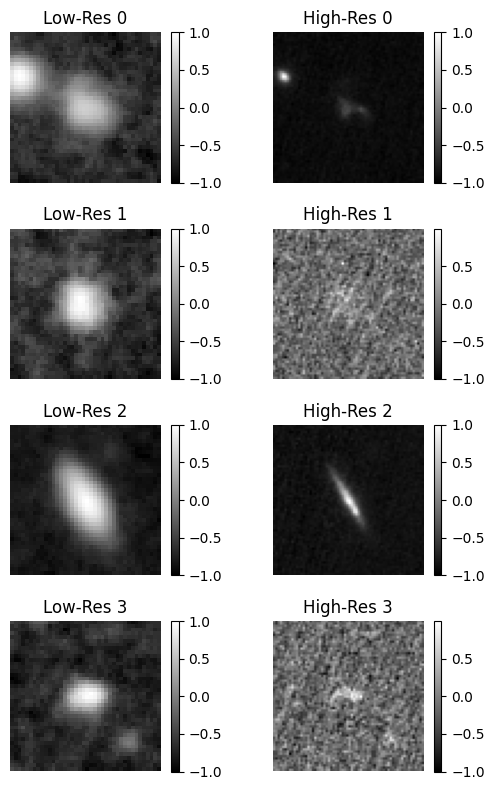

In [3]:
# Define dataset paths
lr_hdf5_path = "../data/Nisp_train.hdf5"
hr_hdf5_path = "../data/Nircam_train.hdf5"

# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()


# Diffusion based model

In [4]:
import torch
import torch.nn as nn

# UNet with Cross-Attention
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        # Ensure condition matches x channels
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 4, num_heads=4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, condition):
        x = x.to(next(self.parameters()).device) 
        condition = condition.to(next(self.parameters()).device)

        x = self.encoder(x)
        condition = self.condition_proj(condition)

        batch_size, channels, height, width = x.shape

        # Flatten height & width dimensions before attention
        x = x.flatten(2).permute(2, 0, 1)
        condition = condition.flatten(2).permute(2, 0, 1)

        x, _ = self.cross_attention(x, condition, condition)

        # Reshape back to image format
        x = x.permute(1, 2, 0).view(batch_size, channels, height, width)
        x = self.decoder(x)
        return x

# Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=100):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)
        condition = condition.to(next(self.parameters()).device)
        return self.unet(x, condition)

class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.upsample = nn.Upsample(size=(66, 66), mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)  
        x = self.upsample(x)
        return self.conv(x)

# Full Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)

        upscaled = self.upsampler(x)

        # Add progressive noise instead of replacing
        noise = torch.randn_like(upscaled, device=upscaled.device)  
        alpha_t = torch.sqrt(1 - (t / self.diffusion.timesteps).float().view(-1, 1, 1, 1))
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        return self.diffusion(noisy_image, t, upscaled)

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape)  



Output shape: torch.Size([1, 1, 66, 66])


# Train

In [7]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 3

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="train", sample_fraction=0.1),
    batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=128, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")


Starting Epoch 1...
Epoch [1/3], Loss: 0.543932, Time: 16.33s
Starting Epoch 2...
Epoch [2/3], Loss: 0.172746, Time: 16.07s
Starting Epoch 3...
Epoch [3/3], Loss: 0.068437, Time: 16.20s
Model saved successfully!


# Evaluate 

In [ ]:
import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import random

# Load model
checkpoint_path = "super_resolution_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=16,  # Best balance
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True
)



In [ ]:
# Select a random batch **without loading all**
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution images using AMP (faster)
with torch.no_grad(), torch.cuda.amp.autocast():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Move back to CPU

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  
sr_batch_np = sr_batch.cpu().squeeze().numpy()  
hr_batch_np = hr_batch.cpu().squeeze().numpy()  

# Plot results
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
# PSNR function using torchmetrics
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.image.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function using skimage
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Set model to evaluation mode
model.eval()

# Fetch a test batch from test_loader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=1, shuffle=True, num_workers=0  
)

lr_test, hr_test = next(iter(test_loader))  
lr_test, hr_test = lr_test.to(device), hr_test.to(device)

# Generate super-resolution image
with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()  # Move result to CPU

# Compute PSNR & SSIM
psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")


In [ ]:
import time

for batch_size in [4, 8, 16, 32, 64]:  # Try different batch sizes
    test_loader = DataLoader(
        SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        prefetch_factor=4,
        persistent_workers=True
    )

    start = time.time()
    lr_batch, hr_batch = next(iter(test_loader))
    end = time.time()

    print(f"Batch size {batch_size}: Data loading time = {end - start:.3f} seconds")


# with W&B

In [ ]:
# Initialize Weights & Biases
wandb.init(
    project="super-resolution-diffusion",
    config={
        "epochs": 50,
        "learning_rate": 1e-4,
        "batch_size": 16, 
        "optimizer": "AdamW",
        "loss_function": "MSELoss"
    }
)

# Enable CuDNN Optimization
torch.backends.cudnn.benchmark = True  

# Define loss function & optimizer
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU
model.to(device)

# Verify if model parameters are on GPU
for name, param in model.named_parameters():
    print(f"{name} is on {param.device}")  

# Train-Test Dataloaders
# Optimized Training DataLoader
train_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="train"),
    batch_size=wandb.config["batch_size"],  # Keep 16 as default if tuning dynamically
    shuffle=True,  # Necessary for training
    num_workers=4,  # Optimized for HDF5
    pin_memory=True, 
    persistent_workers=True
)

# Optimized Test DataLoader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=wandb.config["batch_size"],  # Keep 16 as default if tuning dynamically
    shuffle=False,  # No need to shuffle test data
    num_workers=2,  # Reduce since test data isn't shuffled
    pin_memory=True, 
    persistent_workers=True
)


scaler = torch.amp.GradScaler(device='cuda')  

# Training loop
num_epochs = wandb.config["epochs"]
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...")

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):
        start_batch_time = time.time()  # Measure batch processing time

        lr_batch, hr_batch = lr_batch.to(device, non_blocking=True), hr_batch.to(device, non_blocking=True)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):  
            output = model(lr_batch, t)
            loss = criterion(output, hr_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.cuda.synchronize()  # Forces GPU to execute computations immediately

        batch_time = time.time() - start_batch_time

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    # Log to WandB
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "time_per_epoch": elapsed_time
    })

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

wandb.finish()

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")


In [ ]:
import torch
import wandb
import numpy as np
from torch.utils.data import DataLoader

# Initialize WandB
if wandb.run is None:
    wandb.init(project="super-resolution-diffusion-eval")

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

checkpoint_path = "super_resolution_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define dataset and DataLoader
lr_hdf5_path = "../data/Nisp_train.hdf5"
hr_hdf5_path = "../data/Nircam_train.hdf5"
test_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Fetch a test batch
lr_batch, hr_batch = next(iter(test_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test)

# Move tensors to CPU & detach
lr_batch = lr_batch.cpu().detach().numpy()
sr_batch = sr_batch.cpu().detach().numpy()
hr_batch = hr_batch.cpu().detach().numpy()

# Ensure batch size does not exceed available images
num_samples = min(4, lr_batch.shape[0])

# Convert to valid image range [0, 255] & prevent NaNs
def normalize_image(img):
    img = np.nan_to_num(img)  # Replace NaNs with 0
    img = (img - np.min(img, axis=(0, 1), keepdims=True)) / (np.ptp(img, axis=(0, 1), keepdims=True) + 1e-8)
    return (img * 255).astype(np.uint8)

# Prepare images for WandB
table = wandb.Table(columns=["Low-Res", "Super-Res", "High-Res"])
for i in range(num_samples):
    lr_img = normalize_image(lr_batch[i].squeeze())
    sr_img = normalize_image(sr_batch[i].squeeze())
    hr_img = normalize_image(hr_batch[i].squeeze())

    table.add_data(wandb.Image(lr_img, caption=f"Low-Res {i}"),
                   wandb.Image(sr_img, caption=f"Super-Res {i}"),
                   wandb.Image(hr_img, caption=f"High-Res {i}"))

# Log results to WandB
wandb.log({"Super-Resolution Results": table})

wandb.finish()
